In [6]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict
from math import comb 



In [7]:
# Configuración reproducible
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Parámetros del problema
MIN_ESPACIO = 4.0          # La separación mínima permitida entre aviones, medida en minutos de tiempo de vuelo.
ESPACIO_OBJETIVO = 5.0       # Valor objetivo de separación: los aviones intentan mantener 5 minutos de distancia como buffer de seguridad adicional, si están muy cerca, el avión de atrás baja la velocidad hasta aumentar ese gap a 5.
RADAR_NM = 100.0           # Distancia en millas náuticas (mn) a la que los aviones entran en el radar de Aeroparque (AEP). Cada avión aparece “en la simulación” en este punto inicial.
VELOCIDAD_DE_RETROCESO_KTS = 200.0  # Si un avión no puede mantener la separación (porque debería ir más lento que el mínimo permitido), se sale de la fila y vuela hacia atrás a 200 nudos hasta encontrar un hueco (o salirse del radar a Montevideo, según el caso). Es la velocidad que se usa en ese modo “retrocediendo”.
NUDOS_A_MNxMIN = 1.0 / 60.0  # conversión nudos -> mn/min

In [9]:
def rango_de_velocidad_permitido(distancia_a_mn: float) -> Tuple[float, float]:
    """Devuelve (min_kts, max_kts) permitidos según la tabla del enunciado."""
    if distancia_a_mn > 100.0:
        return 300.0, 500.0
    elif distancia_a_mn > 50.0:
        return 250.0, 300.0   # 100..50
    elif distancia_a_mn > 15.0:
        return 200.0, 250.0   # 50..15
    elif distancia_a_mn > 5.0:
        return 150.0, 200.0   # 15..5
    else:
        return 120.0, 150.0   # 5..0

In [10]:
@dataclass
class Avion:
    avion_id: int
    tiempo_de_aparicion: int
    distancia_a_mn: float = RADAR_NM
    velocidad_kts: float = 0.0
    estado: str = "acercandose"  # acercandose | retrocediendo | desviado | aterrizado
    tiempo_de_aterrizaje: Optional[int] = None
    tiempo_de_desvio: Optional[int] = None
    historial_de_tiempos: List[int] = field(default_factory=list)
    historial_de_distancias: List[float] = field(default_factory=list)
    congestionado: bool = False


    def registrar(self, t: int):
        """
        Guarda en las listas de trayectoria el tiempo actual y la distancia 
        del avión a la pista.
        """
        self.historial_de_tiempos.append(t) #Agrega el instante actual t a la lista historial_de_tiempos.
        self.historial_de_distancias.append(self.distancia_a_mn) #Agrega la distancia del avion a la pista en el momento t a la lista historial_de_distancias.

    def tiempo_estimado_de_llegada(self) -> Optional[float]:
        if self.estado != "acercandose" or self.velocidad_kts <= 0.0:
            return None
        return self.distancia_a_mn / (self.velocidad_kts * NUDOS_A_MNxMIN)

In [13]:
class AEP:
    """Simulación Monte Carlo de arribos y aproximación a AEP.

    - Arribos: proceso Bernoulli por minuto con probabilidad λ.
    - Control de separación: si gap temporal < 4 min, seguidor baja 20 kts respecto del líder
      (respetando mínimos del tramo). Si no puede, se va hacia atrás a 200 kts hasta salir del radar.
    - Posición/tiempo: registra trayectoria de cada avión para visualizar.
    """
    def __init__(self, lam: float, T_minutes: int): 
        """
        Inicializa la simulación del aeropuerto, con probabilidad de arribo por minuto (lam)
    
        """
        assert 0.0 < lam <= 1.0 #lamnda tiene que estar entre 0 y 1
        self.lam = lam
        self.T = T_minutes
        self.aviones: List[Avion] = []
        self.next_id = 1

    def generar_si_llega(self, t: int):
        """
        Genera un nuevo avión en el radar si ocurre un arribo en este minuto.
    
        """
        if rng.random() < self.lam:
            _, max_kts = rango_de_velocidad_permitido(RADAR_NM)
            avion = Avion(avion_id=self.next_id, tiempo_de_aparicion=t, distancia_a_mn=RADAR_NM, velocidad_kts=max_kts, estado="acercandose") #creamos el objeto avion con sus datos inciales
            self.aviones.append(avion) #lo agregamos a la lista de aviones que se estan simulando
            self.next_id += 1

    def controlar_separacion(self, t: int):
        """
        Ajusta las velocidades de los aviones para mantener una separación mínima.
             - Si la separación (gap) es menor que MIN_ESPACIO: El avión que viene atrás reduce velocidad o, si no puede, se va hacia atrás ("retrocediendo").
             - Si la separación es mayor o igual a ESPACIO_OBJETIVO: El avión que viene atrás acelera a su velocidad máxima.
             - Si la separación está entre ambos valores, mantiene su velocidad actual.
        """
        acercandose_: List[Tuple[float, Avion]] = []
        for avion in self.aviones:
            if avion.estado == "acercandose":
                tiempo_estimado_de_llegada = avion.tiempo_estimado_de_llegada()
                if tiempo_estimado_de_llegada is not None:
                    acercandose_.append((t + tiempo_estimado_de_llegada, avion))
        acercandose_.sort(key=lambda x: x[0])  # primero el que llega antes

        for i in range(len(acercandose_) - 1):
            tiempo_estimado_de_llegada_lider, lider = acercandose_[i]
            tiempo_estimado_de_llegada_seguidor, seguidor = acercandose_[i + 1]
            v_min_kts, v_max_kts = rango_de_velocidad_permitido(seguidor.distancia_a_mn)
            gap = tiempo_estimado_de_llegada_seguidor - tiempo_estimado_de_llegada_lider  # minutos

            if gap < MIN_ESPACIO:
                proposed = min(v_max_kts, max(0.0, lider.velocidad_kts - 20.0))
                if proposed < v_min_kts:
                    seguidor.estado = "retrocediendo"
                    seguidor.velocidad_kts = VELOCIDAD_DE_RETROCESO_KTS
                else:
                    seguidor.velocidad_kts = proposed
            elif gap >= ESPACIO_OBJETIVO:
                seguidor.velocidad_kts = v_max_kts
            # Si está entre 4 y 5, mantenemos velocidad para evitar oscilaciones.
    
    def actualización_de_posición(self, t: int):
        for avion in self.aviones:
            if avion.estado == "acercandose":
                min_kts, max_kts = rango_de_velocidad_permitido(avion.distancia_a_mn)

                # --- marcar congestión si está por debajo del máximo permitido del tramo
                if avion.distancia_a_mn < max_kts - 1e-9:   # tolerancia numérica
                    avion.congestionado = True

                # encajar velocidad al rango permitido
                avion.velocidad_kts = max(min(avion.velocidad_kts, max_kts), min_kts)

                # avanzar posición
                avion.distancia_a_mn -= avion.velocidad_kts * NUDOS_A_MNxMIN
                if avion.distancia_a_mn <= 0.0:
                    avion.distancia_a_mn = 0.0
                    avion.estado = "aterrizado"
                    avion.tiempo_de_aterrizaje = t

            elif avion.estado == "retrocediendo":
                avion.distancia_a_mn += VELOCIDAD_DE_RETROCESO_KTS * NUDOS_A_MNxMIN
                if avion.distancia_a_mn >= RADAR_NM + 1e-6:
                    avion.estado = "desviado"
                    avion.tiempo_de_desvio = t

            # registrar trayectoria
            avion.registrar(t)

    def run(self) -> Dict[str, int]:
        for t in range(self.T):
            self.generar_si_llega(t)
            self.controlar_separacion(t)
            self.actualización_de_posición(t)
        aterrizado = sum(1 for avion in self.aviones if avion.estado == "aterrizado")
        desviado = sum(1 for avion in self.aviones if avion.estado == "desviado")
        retrocediendo = sum(1 for avion in self.aviones if avion.estado == "retrocediendo")
        acercandose = sum(1 for avion in self.aviones if avion.estado == "acercandose")
        return {
            "aparecieron": len(self.aviones),
            "aterrizado": aterrizado,
            "desviado": desviado,
            "sigue_retrocediendo": retrocediendo,
            "sigue_acercandose": acercandose,
        }


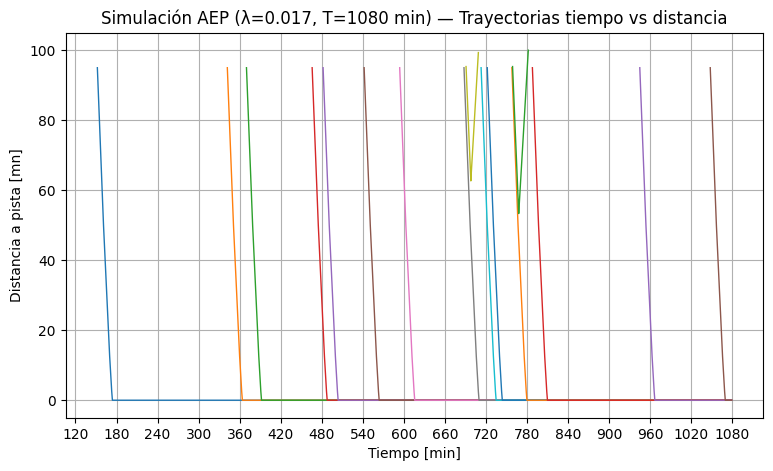

Resumen de la corrida:
- aparecieron: 16
- aterrizado: 14
- desviado: 2
- sigue_retrocediendo: 0
- sigue_acercandose: 0


In [14]:
def run_and_plot(lam: float = 0.017, T_minutes: int = 1080):
    sim = AEP(lam=lam, T_minutes=T_minutes)
    summary = sim.run()

    # Visualización: tiempo vs distancia (una línea por avión)
    plt.figure(figsize=(9, 5))
    for avion in sim.aviones:
        tiempos_arr = np.array(avion.historial_de_tiempos)
        distancias_arr = np.array(avion.historial_de_distancias)
        mask = (distancias_arr >= 0.0) & (distancias_arr <= RADAR_NM + 1e-6)
        if mask.any():
            plt.plot(tiempos_arr[mask], distancias_arr[mask], linewidth=1)
    plt.title(f"Simulación AEP (λ={lam}, T={T_minutes} min) — Trayectorias tiempo vs distancia")
    plt.xlabel("Tiempo [min]")
    plt.ylabel("Distancia a pista [mn]")
    plt.grid(True)
    import matplotlib.ticker as ticker
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(60))
    plt.show()

    print("Resumen de la corrida:")
    for k, v in summary.items():
        print(f"- {k}: {v}")
    return sim, summary

# Parámetros base de demo (podemos cambiarlos y volver a correrlo)
_ = run_and_plot(lam=0.017, T_minutes=1080)



**Notas**
- Este punto 1 **no** incluye aún re-inserción en la cola tras retrocediendo (eso se agrega en los puntos 5–6).
- Para simular todo el día (6:00–00:00) usá `T_minutes = 1080`.
- La figura muestra cada avión como una **línea**: pendiente negativa → aproximación; pendiente positiva y salida del gráfico → desvío.

Punto 2

In [15]:
# Punto 2 - Calcular λ para 1 avión por hora
n_min = 60
avg_arrivals_per_hour = 1

lam = avg_arrivals_per_hour / n_min
print(f"λ = {lam:.6f} (≈ 1/60)")


λ = 0.016667 (≈ 1/60)


Punto 3

In [16]:
lam = 1/60          # probabilidad de arribo por minuto (1 avión/hora)
n_min = 60          # 1 hora = 60 minutos
reps = 200_000      # cantidad de horas simuladas
rng = np.random.default_rng(42)

# --- Simulación Monte Carlo ---
counts = rng.binomial(n=n_min, p=lam, size=reps)
hits = np.sum(counts == 5)
p_hat = hits / reps

# Error estándar e IC95% para la proporción
se = np.sqrt(p_hat * (1 - p_hat) / reps)
ci95 = (p_hat - 1.96*se, p_hat + 1.96*se)

print(f"Reps: {reps:,}")
print(f"Veces con 5 arribos: {hits:,}")
print(f"Estimación Monte Carlo P(N=5): {p_hat:.6f}")
print(f"SE: {se:.6f}  IC95%: ({ci95[0]:.6f}, {ci95[1]:.6f})")

# --- Comparación analítica (Binomial exacto) ---
p_exact = comb(n_min, 5) * (lam**5) * ((1-lam)**(n_min-5))
print(f"Probabilidad exacta (Binomial): {p_exact:.6f}")

Reps: 200,000
Veces con 5 arribos: 569
Estimación Monte Carlo P(N=5): 0.002845
SE: 0.000119  IC95%: (0.002612, 0.003078)
Probabilidad exacta (Binomial): 0.002787


# Punto 4 - Experimentos por distintos λ: congestión, atrasos y desvíos
## Ampliamos el simulador para medir congestión, atrasos vs. vuelo libre y desvíos.



=== λ = 0.02 ===
aparecieron: 20
aterrizado: 18
desviado: 2
sigue_retrocediendo: 0
sigue_acercandose: 0


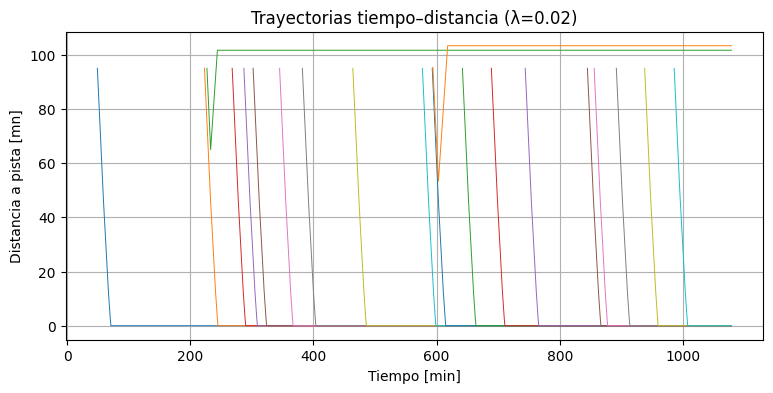


=== λ = 0.1 ===
aparecieron: 109
aterrizado: 67
desviado: 39
sigue_retrocediendo: 1
sigue_acercandose: 2


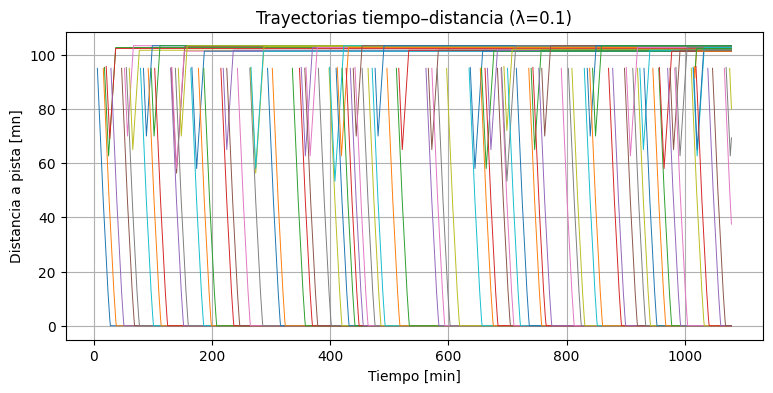


=== λ = 0.2 ===
aparecieron: 225
aterrizado: 100
desviado: 122
sigue_retrocediendo: 1
sigue_acercandose: 2


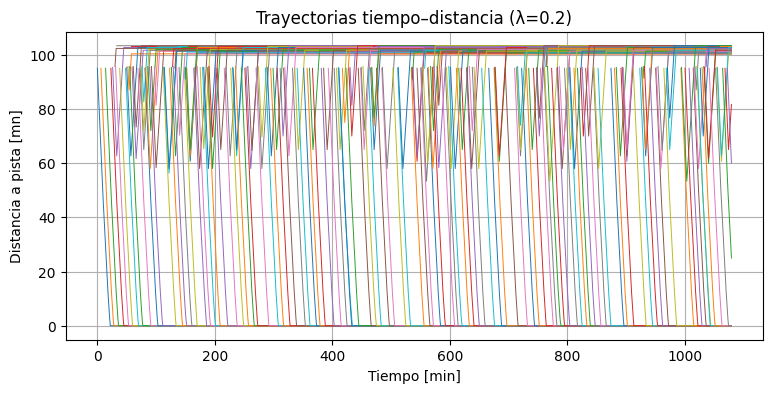


=== λ = 0.5 ===
aparecieron: 527
aterrizado: 131
desviado: 390
sigue_retrocediendo: 3
sigue_acercandose: 3


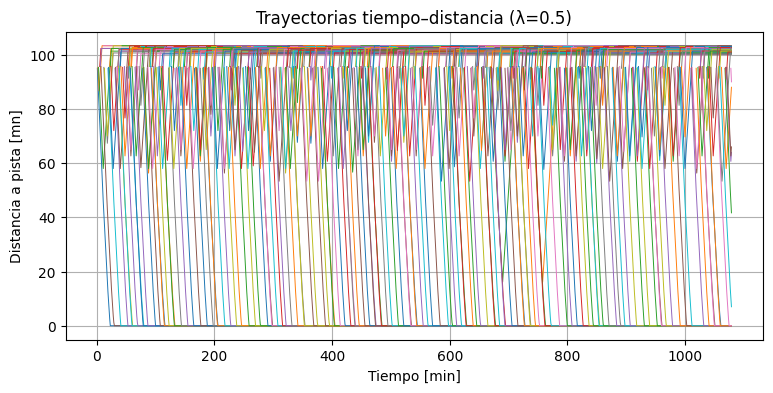


=== λ = 1.0 ===
aparecieron: 1080
aterrizado: 211
desviado: 861
sigue_retrocediendo: 0
sigue_acercandose: 8


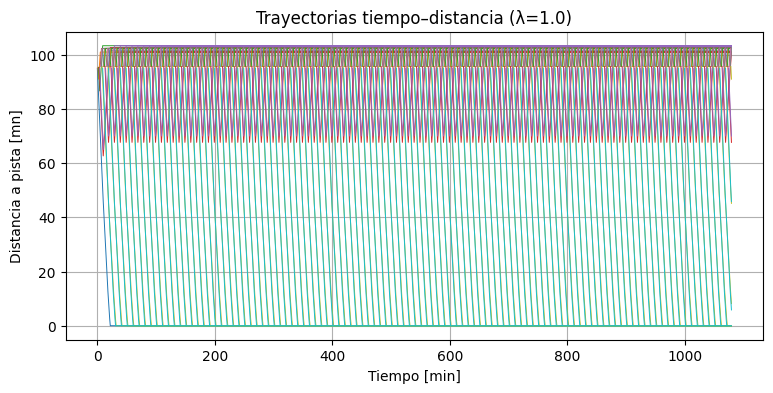

In [17]:

lam_list = [0.02, 0.1, 0.2, 0.5, 1.0]

for lam in lam_list:
    sim = AEP(lam=lam, T_minutes=1080)  # 18 horas
    summary = sim.run()
    print(f"\n=== λ = {lam} ===")
    for k, v in summary.items():
        print(f"{k}: {v}")

    # Gráfico de ejemplo
    import matplotlib.pyplot as plt
    import numpy as np
    plt.figure(figsize=(9,4))
    for avion in sim.aviones:
        t = np.array(avion.historial_de_tiempos); d = np.array(avion.historial_de_distancias)
        if len(t)>0:
            plt.plot(t, d, lw=0.7)
    plt.title(f"Trayectorias tiempo–distancia (λ={lam})")
    plt.xlabel("Tiempo [min]")
    plt.ylabel("Distancia a pista [mn]")
    plt.grid(True)
    plt.show()


In [21]:


# 1) (Si no lo tenés) tiempo ideal de vuelo libre desde 100 mn
def _free_flight_minutes_from_100nm():
    NM_PER_MIN_FROM_KTS = 1.0/60.0
    segs = [
        (100-50, 300.0),  # 100→50 a 300 kts
        (50-15, 250.0),   # 50→15 a 250 kts
        (15-5, 200.0),    # 15→5 a 200 kts
        (5-0, 150.0),     # 5→0 a 150 kts
    ]
    t = 0.0
    for dist_nm, kts in segs:
        t += dist_nm / (kts * (1.0/60.0))
    return t

try:
    FREE_FLIGHT_MIN
except NameError:
    FREE_FLIGHT_MIN = _free_flight_minutes_from_100nm()


# 3) Helpers
def mean_se(values):
    arr = np.array(values, dtype=float)
    m = float(arr.mean()) if arr.size else float("nan")
    se = float(arr.std(ddof=1)/np.sqrt(arr.size)) if arr.size > 1 else float("nan")
    return m, se

def summarize_sim(sim) -> Dict[str, float]:
    """Lee sim.aviones y computa métricas."""
    # 1) PRIMERO obtener y tipar la lista
    aviones: List[Avion] = getattr(sim, "aviones", [])
    aparecieron: int = len(aviones)

    # 2) Filtrados por estado
    aterrizado: List[Avion] = [a for a in aviones if getattr(a, "estado", None) == "aterrizado"]
    desviado: int = sum(1 for a in aviones if getattr(a, "estado", None) == "desviado")

    # 3) Tasa de congestión (si existe el flag)
    if aviones and hasattr(aviones[0], "congestionado"):
        congestionados = sum(1 for a in aviones if getattr(a, "congestionado", False))
        tasa_de_congestion = (congestionados / aparecieron) if aparecieron else float("nan")
    else:
        tasa_de_congestion = float("nan")

    # 4) Atraso promedio (min) vs vuelo libre
    delays: List[float] = []
    for a in aterrizado:
        t_aparicion: Optional[int] = getattr(a, "tiempo_de_aparicion", getattr(a, "entry_min", None))
        t_aterrizaje: Optional[int] = getattr(a, "tiempo_de_aterrizaje", getattr(a, "landed_at", None))
        if (t_aparicion is not None) and (t_aterrizaje is not None):
            delay = t_aterrizaje - (t_aparicion + FREE_FLIGHT_MIN)
            if delay < 0:
                delay = 0.0
            delays.append(float(delay))
    avg_delay_min = float(np.mean(delays)) if delays else 0.0

    tasa_de_desvio = (desviado / aparecieron) if aparecieron else float("nan")

    return {
        "aparecieron": float(aparecieron),
        "aterrizado": float(len(aterrizado)),
        "tasa_de_desvio": float(tasa_de_desvio),
        "tasa_de_congestion": float(tasa_de_congestion),
        "avg_delay_min": float(avg_delay_min),
    }

def evaluate_lambda(lam, reps=50, T_minutes=1080, show_example_plot=False):
    """Corre varias simulaciones y reporta media ± SE de las métricas."""
    tasa_de_desvio, tasa_de_congestion, delays = [], [], []
    lista_de_aterrizados, lista_de_apariciones = [], []

    for _ in range(reps):
        sim = AEP(lam=lam, T_minutes=T_minutes)
        _ = sim.run()
        m = summarize_sim(sim)
        lista_de_apariciones.append(m["aparecieron"])
        lista_de_aterrizados.append(m["aterrizado"])
        tasa_de_desvio.append(m["tasa_de_desvio"])
        tasa_de_congestion.append(m["tasa_de_congestion"])
        delays.append(m["avg_delay_min"])


    sm, _  = mean_se(lista_de_apariciones)
    lm, _  = mean_se(lista_de_aterrizados)
    drm, drse = mean_se(tasa_de_desvio)
    cgm, cgse = mean_se(tasa_de_congestion)
    adm, adse = mean_se(delays)

    print(f"\nλ={lam} | reps={reps} | T={T_minutes} min")
    print(f"- Promedio de apariciones: {sm:.1f}   Promedio de aterrizajes: {lm:.1f}")
    print(f"- Congestión: {cgm:.3f} ± {cgse:.003f} (fracción de aviones)")
    print(f"- Atraso promedio: {adm:.3f} ± {adse:.003f} min")
    print(f"- Desvío a Montevideo: {drm:.3f} ± {drse:.003f} (fracción)")

    if show_example_plot:
        # una corrida de ejemplo para ver las trayectorias
        sim = AEP(lam=lam, T_minutes=360)
        _ = sim.run()
        plt.figure(figsize=(9,4))
        for avion in sim.aviones:
            t = np.array(getattr(avion, "historial_de_tiempos", []))
            d = np.array(getattr(avion, "historial_de_distancia", []))
            if t.size and d.size:
                plt.plot(t, d, lw=0.7)
        plt.title(f"Trayectorias tiempo–distancia (ejemplo, λ={lam})")
        plt.xlabel("Tiempo [min]"); plt.ylabel("Distancia a pista [mn]")
        plt.grid(True); plt.show()

# 4) Ejecutá para los λ pedidos
for lam in [0.02, 0.1, 0.2, 0.5, 1.0]:
    evaluate_lambda(lam, reps=60, T_minutes=1080, show_example_plot=False)



λ=0.02 | reps=60 | T=1080 min
- Promedio de apariciones: 21.7   Promedio de aterrizajes: 19.4
- Congestión: 1.000 ± 0.000 (fracción de aviones)
- Atraso promedio: 0.000 ± 0.000 min
- Desvío a Montevideo: 0.092 ± 0.007 (fracción)

λ=0.1 | reps=60 | T=1080 min
- Promedio de apariciones: 107.6   Promedio de aterrizajes: 68.0
- Congestión: 0.985 ± 0.001 (fracción de aviones)
- Atraso promedio: 0.004 ± 0.001 min
- Desvío a Montevideo: 0.346 ± 0.005 (fracción)

λ=0.2 | reps=60 | T=1080 min
- Promedio de apariciones: 216.4   Promedio de aterrizajes: 95.0
- Congestión: 0.924 ± 0.002 (fracción de aviones)
- Atraso promedio: 0.029 ± 0.003 min
- Desvío a Montevideo: 0.542 ± 0.004 (fracción)

λ=0.5 | reps=60 | T=1080 min
- Promedio de apariciones: 545.3   Promedio de aterrizajes: 128.0
- Congestión: 0.778 ± 0.002 (fracción de aviones)
- Atraso promedio: 0.137 ± 0.004 min
- Desvío a Montevideo: 0.754 ± 0.001 (fracción)

λ=1.0 | reps=60 | T=1080 min
- Promedio de apariciones: 1080.0   Promedio de a